In [1]:
import pandas as pd
import numpy as np
import json
import pickle
import joblib

from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.feature_selection import SequentialFeatureSelector
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, BatchNormalization, Dropout, Input
from tensorflow.keras.layers import MultiHeadAttention, GlobalAveragePooling1D
import os
from scipy.interpolate import interp1d
from scipy.signal import find_peaks, savgol_filter
import seaborn as sns
import matplotlib.pyplot as plt
import time
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
# Paths
CYCLES_DIR = Path("D:/PD/PD_latest/dataset/processed_cycles/fog/turn/cycles")
METADATA_PATH = Path("D:/PD/PD_latest/dataset/processed_cycles/fog/turn/metadata/cycle_metadata.csv")
OUTPUT_DIR = Path("models/turn_features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
TIMESTEPS = 60
KEYPOINTS_PER_TIMESTEP = 34

# Data parameters
NUM_CYCLES = 6
FILE_ID_COLUMN = 'file_id'

**Feature Engineering**

In [3]:
def kp_xy(row, joint_name):
    # Implement based on how your data is structured
    # For example:
    idx = KEYPOINTS[joint_name]
    x_col = f'keypoint_{idx * 2}'
    y_col = f'keypoint_{idx * 2 + 1}'
    return row[x_col], row[y_col]

def compute_angle(ax, ay, bx, by, cx, cy):
    # Calculate angle at point B
    vec1 = np.array([ax - bx, ay - by])
    vec2 = np.array([cx - bx, cy - by])
    cosine_angle = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2) + 1e-8)
    angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
    return np.degrees(angle)

def safe_savgol(data, window_length=5, polyorder=2):
    if len(data) < window_length:
        return data
    return savgol_filter(data, window_length, polyorder)

# FOG feature extraction utilities
def normalize_keypoints(xy_seq):
    """Normalize each frame into a fixed 80-unit box after 30% bbox expansion."""
    if xy_seq is None or len(xy_seq) == 0:
        return np.zeros((0, 34), dtype=np.float32)
    
    pts = np.asarray(xy_seq, dtype=np.float32).reshape(-1, 17, 2)
    norm_seq = []
    
    for frame in pts:
        x = frame[:, 0]
        y = frame[:, 1]
        
        xmin, xmax = np.nanmin(x), np.nanmax(x)
        ymin, ymax = np.nanmin(y), np.nanmax(y)
        
        width = xmax - xmin
        height = ymax - ymin
        
        if not np.isfinite(width) or width == 0:
            width = 1.0
        if not np.isfinite(height) or height == 0:
            height = 1.0
        
        xmin -= 0.15 * width
        xmax += 0.15 * width
        ymin -= 0.15 * height
        ymax += 0.15 * height
        
        denom = ymax - ymin
        if denom == 0:
            denom = 1.0
        scale = 80.0 / denom
        
        x_norm = (x - xmin) * scale
        y_norm = (y - ymin) * scale
        norm_seq.append(np.stack([x_norm, y_norm], axis=1))
    
    return np.array(norm_seq, dtype=np.float32).reshape(-1, 34)

def compute_motion_features(xy_seq, fps=30):
    """Return averaged ankle speed and speed-acceleration signals."""
    arr = np.asarray(xy_seq, dtype=np.float32)
    if arr.ndim != 2 or arr.shape[1] != 34:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32)
    
    xL = arr[:, 15 * 2]
    yL = arr[:, 15 * 2 + 1]
    xR = arr[:, 16 * 2]
    yR = arr[:, 16 * 2 + 1]
    
    vL = np.sqrt(np.diff(xL, prepend=xL[0]) ** 2 + np.diff(yL, prepend=yL[0]) ** 2) * fps
    vR = np.sqrt(np.diff(xR, prepend=xR[0]) ** 2 + np.diff(yR, prepend=yR[0]) ** 2) * fps
    speed = (vL + vR) / 2.0
    
    acc = np.diff(speed, prepend=speed[0]) * fps
    return speed.astype(np.float32), acc.astype(np.float32)

def compute_freezing_index(window, fs=30):
    """Compute freezing index from FFT of speed signal."""
    freqs = np.fft.rfftfreq(len(window), d=1 / fs)
    fft_vals = np.abs(np.fft.rfft(window)) ** 2
    
    locomotor_band = (freqs >= 0.5) & (freqs < 3)
    freeze_band = (freqs >= 3) & (freqs <= 8)
    
    power_loco = np.sum(fft_vals[locomotor_band])
    power_freeze = np.sum(fft_vals[freeze_band])
    
    if power_loco == 0:
        return 0.0
    
    return float(power_freeze / power_loco)

def extract_fog_features(xy_seq, fps=30):
    """Extract only the freezing index from a sequence of keypoints."""
    if xy_seq is None or len(xy_seq) == 0:
        return {'freezing_index': 0.0}
    
    xy_norm = normalize_keypoints(xy_seq)
    speed, _ = compute_motion_features(xy_norm, fps=fps)
    
    if len(speed) == 0:
        return {'freezing_index': 0.0}
    
    freezing_index = compute_freezing_index(speed, fs=fps)
    return {'freezing_index': freezing_index}

In [4]:
df_meta = pd.read_csv(METADATA_PATH)
print(f"Total cycles: {len(df_meta)} from {df_meta['file_id'].nunique()} files")

# Check cycles per file
cycle_counts = df_meta['file_id'].value_counts()
if not cycle_counts.eq(NUM_CYCLES).all():
    bad = cycle_counts[cycle_counts != NUM_CYCLES]
    raise ValueError(f"Some files don’t have {NUM_CYCLES} cycles: {bad.index.tolist()}")

unique_files = df_meta['file_id'].unique()

Total cycles: 240 from 40 files


In [5]:
df_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   file_id               240 non-null    object 
 1   cycle_id              240 non-null    int64  
 2   start_frame           240 non-null    int64  
 3   end_frame             240 non-null    int64  
 4   n_frames_raw          240 non-null    int64  
 5   is_padded             240 non-null    bool   
 6   detected_using        240 non-null    object 
 7   original_cycle_count  240 non-null    int64  
 8   label                 240 non-null    int64  
 9   source                240 non-null    object 
 10  fog_ratio             240 non-null    float64
 11  mean_fi               240 non-null    float64
 12  max_fi                240 non-null    float64
 13  fog_events            240 non-null    int64  
dtypes: bool(1), float64(3), int64(7), object(3)
memory usage: 24.7+ KB


**Data Splitting**

In [6]:
file_labels = df_meta.groupby('file_id')['label'].first().reindex(unique_files).values
files_df = pd.DataFrame({'file_id': unique_files, 'label': file_labels})

train_files, temp = train_test_split(files_df, test_size=0.3, stratify=files_df['label'], random_state=SEED)
val_files, test_files = train_test_split(temp, test_size=0.5, stratify=temp['label'], random_state=SEED)

train_set = set(train_files['file_id'])
val_set = set(val_files['file_id'])
test_set = set(test_files['file_id'])

print(f"Split sizes (subjects): Train={len(train_set)}, Val={len(val_set)}, Test={len(test_set)}")

Split sizes (subjects): Train=28, Val=6, Test=6


In [7]:
file_cycle_features = {}
for file_id, group in tqdm(df_meta.groupby('file_id'), desc="Loading raw cycles"):
    group = group.sort_values('cycle_id')
    label = int(group['label'].iloc[0])
    cycles_raw = []

    for _, row in group.iterrows():
        json_path = os.path.join(CYCLES_DIR, f"{row['file_id']}_cycle_{row['cycle_id']}.json")
        with open(json_path, 'r') as f:
            cyc = json.load(f)
        xy = np.array(cyc['xy'])
        L = xy.shape[0]
        # Resample
        if L == 0:
            res = np.zeros((TIMESTEPS, KEYPOINTS_PER_TIMESTEP))
        elif L == 1:
            res = np.tile(xy[0], (TIMESTEPS, 1))
        elif L == TIMESTEPS:
            res = xy
        else:
            x_old = np.linspace(0, 1, L)
            x_new = np.linspace(0, 1, TIMESTEPS)
            res = np.column_stack([
                interp1d(x_old, xy[:, i], kind='linear', fill_value="extrapolate")(x_new)
                for i in range(KEYPOINTS_PER_TIMESTEP)
            ])
        cycles_raw.append(res)
    file_cycle_features[file_id] = {'cycles': cycles_raw, 'label': label}

Loading raw cycles: 100%|██████████| 40/40 [00:00<00:00, 41.90it/s]


In [8]:
# COCO-style keypoint order
KEYPOINTS = {
    'nose': 0, 'left_eye': 1, 'right_eye': 2, 'left_ear': 3, 'right_ear': 4,
    'left_shoulder': 5, 'right_shoulder': 6, 'left_elbow': 7, 'right_elbow': 8,
    'left_wrist': 9, 'right_wrist': 10, 'left_hip': 11, 'right_hip': 12,
    'left_knee': 13, 'right_knee': 14, 'left_ankle': 15, 'right_ankle': 16,
}

In [9]:
def get_label_from_file_id(file_id):
    if 'NP' in file_id:
        return 0
    elif 'PD' in file_id:
        return 1
    else:
        # Handle unexpected cases
        return -1  # or raise an error

In [10]:
FEATURE_COLS = [
    # FOG Features
    'freezing_index',
]

In [11]:
# Define columns for your cycle DataFrame
cols = [f'keypoint_{i}' for i in range(KEYPOINTS_PER_TIMESTEP)]

# Initialize dictionaries
file_features = {}
file_cycle_feature_seqs = {}

# Group the metadata by file_id
grouped = df_meta.groupby('file_id')

for file_id, group in tqdm(grouped, desc="Processing files"):
    label = get_label_from_file_id(file_id)

    cycle_feats = []
    cycles_per_frame = []

    for _, row in group.iterrows():
        # Load cycle json
        json_path = os.path.join(CYCLES_DIR, f"{row['file_id']}_cycle_{row['cycle_id']}.json")
        with open(json_path, 'r') as f:
            cyc = json.load(f)

        xy = np.array(cyc['xy'])  # shape: (L, 34)
        L = xy.shape[0]

        # Resample to fixed TIMESTEPS
        if L == 0:
            res = np.zeros((TIMESTEPS, KEYPOINTS_PER_TIMESTEP))
        elif L == 1:
            res = np.tile(xy[0], (TIMESTEPS, 1))
        elif L == TIMESTEPS:
            res = xy
        else:
            x_old = np.linspace(0, 1, L)
            x_new = np.linspace(0, 1, TIMESTEPS)
            res = np.column_stack([
                interp1d(x_old, xy[:, i], kind='linear', fill_value="extrapolate")(x_new)
                for i in range(KEYPOINTS_PER_TIMESTEP)
            ])

        # Create DataFrame for the full cycle
        df_cycle = pd.DataFrame(res, columns=cols)

        # Compute CYCLE-AGGREGATED features
        feats = {}
        feats.update(extract_fog_features(res, fps=30))
        cycle_feats.append(feats)

        # Compute FOG features once per cycle to reuse for each frame
        fog_feats = extract_fog_features(res, fps=30)

        # Compute PER-FRAME features for all timesteps
        per_frame_feats = []
        for t in range(TIMESTEPS):
            df_frame = df_cycle.iloc[[t]]

            frame_feat_dict = {}
            frame_feat_dict.update(fog_feats)

            frame_vals = [frame_feat_dict.get(col, 0.0) for col in FEATURE_COLS]
            per_frame_feats.append(frame_vals)

        cycle_array = np.array(per_frame_feats, dtype=np.float32)
        cycles_per_frame.append(cycle_array)

    # Store per-file outputs
    file_features[file_id] = {
        'cycle_features': cycle_feats,
        'label': label
    }

    file_cycle_feature_seqs[file_id] = {
        'cycles': cycles_per_frame,
        'label': label
    }

Processing files: 100%|██████████| 40/40 [00:03<00:00, 12.13it/s]


In [12]:
# Example feature extraction for keypoints
keypoint_features = ['x', 'y', 'confidence']
keypoint_indices = {name: idx for name, idx in KEYPOINTS.items()}

# Initialize list to store features per file
subject_features = []

for file_id, data in file_features.items():
    df_cycle_feats = pd.DataFrame(data['cycle_features'])
    mean_feat = {}
    for key in FEATURE_COLS:
        vals = df_cycle_feats.get(key, pd.Series()).dropna().values
        if len(vals) > 0:
            mean_val = float(np.nanmean(vals))
        else:
            mean_val = 0.0
        mean_feat[key] = mean_val
    # Add the file_id to the feature dict
    mean_feat['file_id'] = file_id
    # Add label
    mean_feat['label'] = data['label']
    subject_features.append(mean_feat)

df_features = pd.DataFrame(subject_features)

print(f"Feature matrix shape: {df_features.shape}")
print(f"Columns: {df_features.columns.tolist()}")

Feature matrix shape: (40, 3)
Columns: ['freezing_index', 'file_id', 'label']


In [13]:
df_features.head()

,freezing_index,file_id,label
0,1.240975,NP_front_1,0
1,0.308779,NP_front_12,0
2,1.498847,NP_front_2,0
3,0.585521,NP_front_6,0
4,0.181974,NP_front_9,0


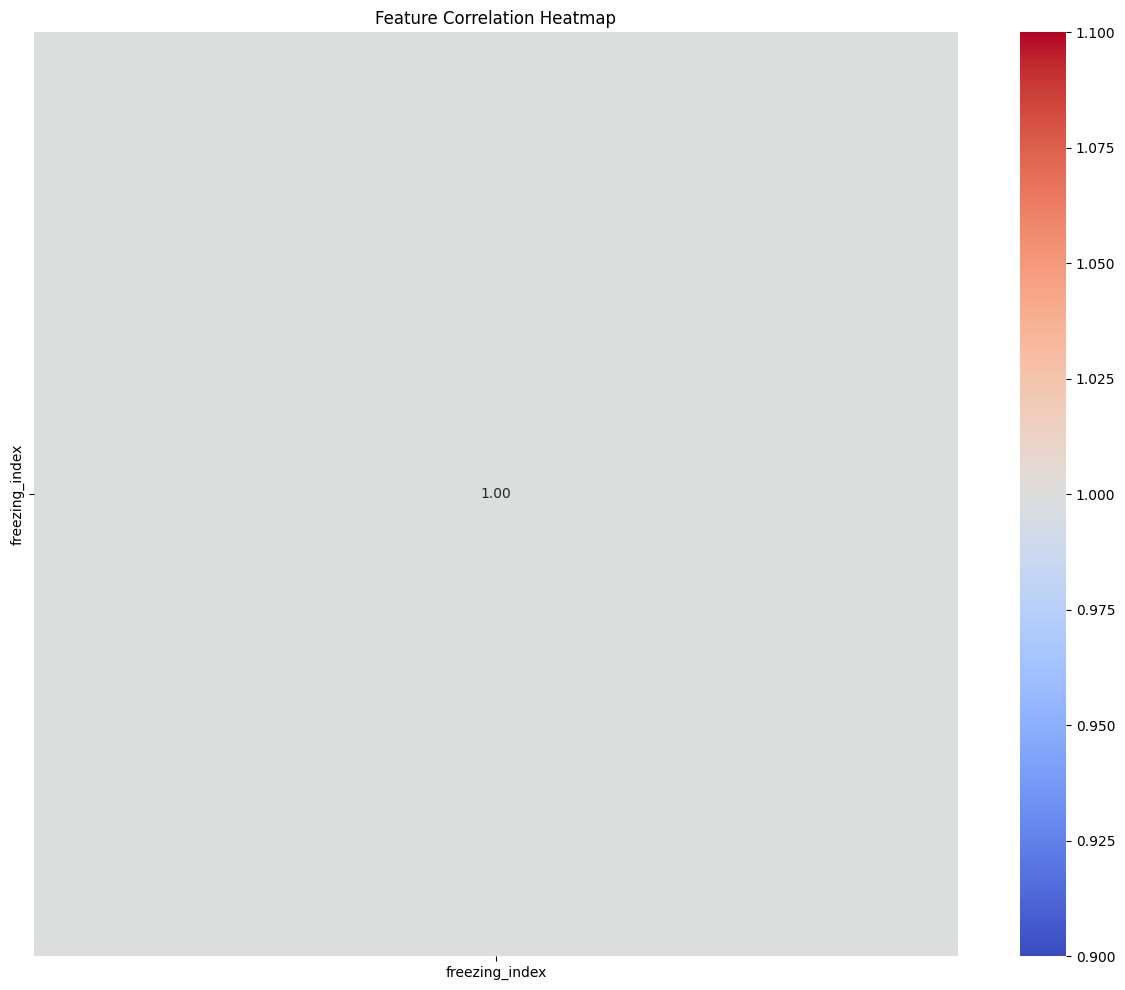

In [14]:
# heatmap of feature correlations
plt.figure(figsize=(16, 12))
corr = df_features[FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [15]:
# shows min, max, overall mean, NP mean, PD mean for each features
mean_NP  = df_features[df_features['label'] == 0][FEATURE_COLS].mean()
mean_PD  = df_features[df_features['label'] == 1][FEATURE_COLS].mean()
summary_stats = df_features[FEATURE_COLS].agg(['min', 'max', 'mean']).T
summary_stats['NP_mean'] = mean_NP
summary_stats['PD_mean'] = mean_PD
display(summary_stats.round(2))

,min,max,mean,NP_mean,PD_mean
freezing_index,0.18,1.89,0.79,0.74,0.83


In [16]:
# Prepare 3D data (samples, timesteps, features) for LSTM models
# Group cycles by cycle count (1 to 6)

samples_3d = {n: [] for n in range(1, 7)}
labels_3d = {n: [] for n in range(1, 7)}
file_ids_3d = {n: [] for n in range(1, 7)}

print("Building non-overlapping cycle groups...")
for file_id, data in file_cycle_features.items():
    cycles_raw = data['cycles']  # List of 6 cycles, each (60, 34)
    label = data['label']
    
    for n in range(1, 7):
        # Create non-overlapping groups of n cycles
        groups = [
            cycles_raw[start:start + n]
            for start in range(0, 6, n)
            if start + n <= 6
        ]
        for group in groups:
            combined = np.concatenate(group, axis=0)  # (n*60, 34)
            samples_3d[n].append(combined)
            labels_3d[n].append(label)
            file_ids_3d[n].append(file_id)

# Convert to arrays
for n in range(1, 7):
    samples_3d[n] = np.array(samples_3d[n], dtype=np.float32)
    labels_3d[n] = np.array(labels_3d[n], dtype=int)
    file_ids_3d[n] = np.array(file_ids_3d[n])
    print(f"  {n}-cycle(s): {len(samples_3d[n])} samples, shape {samples_3d[n].shape}")


Building non-overlapping cycle groups...
  1-cycle(s): 240 samples, shape (240, 60, 34)
  2-cycle(s): 120 samples, shape (120, 120, 34)
  3-cycle(s): 80 samples, shape (80, 180, 34)
  4-cycle(s): 40 samples, shape (40, 240, 34)
  5-cycle(s): 40 samples, shape (40, 300, 34)
  6-cycle(s): 40 samples, shape (40, 360, 34)


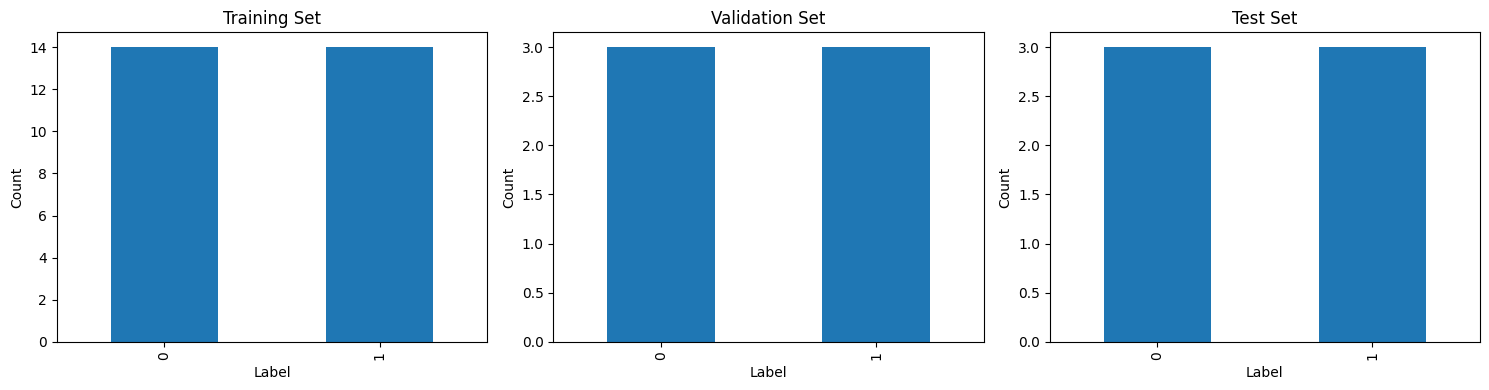

In [17]:
import matplotlib.pyplot as plt

# Create boolean masks for train/val/test sets
train_mask = df_features['file_id'].isin(train_set)
val_mask = df_features['file_id'].isin(val_set)
test_mask = df_features['file_id'].isin(test_set)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, mask, title in zip(axes, [train_mask, val_mask, test_mask],
                           ['Training Set', 'Validation Set', 'Test Set']):
    counts = df_features.loc[mask, 'label'].value_counts()
    counts.plot(kind='bar', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

**Feature Selection**

In [18]:
# Split data by cycle count
# For each cycle count, split into train/val/test using file_ids

cycle_splits = {}
for n in range(1, 7):
    # Get indices for each set based on file_ids
    train_indices = np.where(np.isin(file_ids_3d[n], list(train_set)))[0]
    val_indices = np.where(np.isin(file_ids_3d[n], list(val_set)))[0]
    test_indices = np.where(np.isin(file_ids_3d[n], list(test_set)))[0]
    
    cycle_splits[n] = {
        'X_train': samples_3d[n][train_indices],
        'X_val': samples_3d[n][val_indices],
        'X_test': samples_3d[n][test_indices],
        'y_train': labels_3d[n][train_indices],
        'y_val': labels_3d[n][val_indices],
        'y_test': labels_3d[n][test_indices],
    }
    
    print(f"\n{n}-cycle(s) split:")
    print(f"  Train: {len(cycle_splits[n]['X_train'])} samples")
    print(f"  Val:   {len(cycle_splits[n]['X_val'])} samples")
    print(f"  Test:  {len(cycle_splits[n]['X_test'])} samples")



1-cycle(s) split:
  Train: 168 samples
  Val:   36 samples
  Test:  36 samples

2-cycle(s) split:
  Train: 84 samples
  Val:   18 samples
  Test:  18 samples

3-cycle(s) split:
  Train: 56 samples
  Val:   12 samples
  Test:  12 samples

4-cycle(s) split:
  Train: 28 samples
  Val:   6 samples
  Test:  6 samples

5-cycle(s) split:
  Train: 28 samples
  Val:   6 samples
  Test:  6 samples

6-cycle(s) split:
  Train: 28 samples
  Val:   6 samples
  Test:  6 samples


In [19]:
# FI-only feature selection setup
selected_features = ['freezing_index']

train_mask = df_features['file_id'].isin(train_set)
val_mask = df_features['file_id'].isin(val_set)
test_mask = df_features['file_id'].isin(test_set)

X_train_full = df_features.loc[train_mask, ['freezing_index']].fillna(0.0).copy()
X_val_full = df_features.loc[val_mask, ['freezing_index']].fillna(0.0).copy()
X_test_full = df_features.loc[test_mask, ['freezing_index']].fillna(0.0).copy()

approaches = {
    'full_features': {
        'selected_features': selected_features,
        'X_train': X_train_full,
        'X_val': X_val_full,
        'X_test': X_test_full,
    }
}

print("Selected feature counts:")
for name, data in approaches.items():
    print(f"  {name}: {len(data['selected_features'])} feature(s)")

Selected feature counts:
  full_features: 1 feature(s)


In [21]:
# Precompute 3D feature sequences for all feature selection approaches
# 6 arrays of shape (60, len(FEATURE_COLS)), with columns in FEATURE_COLS order.

approach_splits = {}
# Create a mapping from feature name to its column index in the per-frame data
feature_to_idx = {name: idx for idx, name in enumerate(FEATURE_COLS)}
df_features_by_id = df_features.set_index('file_id')  # still kept for safety, though unused

print("Building 3D feature sequences for each approach...")
for app_name, app_data in approaches.items():
    selected_cols = app_data['selected_features']
    
    # Get column indices for selected features
    selected_indices = [feature_to_idx[col] for col in selected_cols]

    samples_3d = {n: [] for n in range(1, 7)}
    labels_3d = {n: [] for n in range(1, 7)}
    file_ids_3d = {n: [] for n in range(1, 7)}

    for file_id, data in file_cycle_feature_seqs.items():
        cycles = data['cycles']  # list of 6 × (60, len(FEATURE_COLS))
        label = data['label']

        for n in range(1, 7):
            for start in range(0, 6, n):
                if start + n <= 6:
                    group = cycles[start:start + n]  # n cycles
                    stacked = np.concatenate(group, axis=0)  # (n*60, len(FEATURE_COLS))
                    
                    # Select only the chosen feature columns
                    combined = stacked[:, selected_indices]  # (n*60, len(selected_cols))
                    
                    samples_3d[n].append(combined)
                    labels_3d[n].append(label)
                    file_ids_3d[n].append(file_id)

    # Convert to arrays
    for n in range(1, 7):
        if samples_3d[n]:  # avoid empty
            samples_3d[n] = np.array(samples_3d[n], dtype=np.float32)
            labels_3d[n] = np.array(labels_3d[n], dtype=int)
            file_ids_3d[n] = np.array(file_ids_3d[n])
        else:
            D = len(selected_cols)
            samples_3d[n] = np.empty((0, 0, D), dtype=np.float32)
            labels_3d[n] = np.array([])
            file_ids_3d[n] = np.array([])

    # Split into train/val/test by file_id
    cycle_splits_app = {}
    for n in range(1, 7):
        train_idx = np.where(np.isin(file_ids_3d[n], list(train_set)))[0]
        val_idx = np.where(np.isin(file_ids_3d[n], list(val_set)))[0]
        test_idx = np.where(np.isin(file_ids_3d[n], list(test_set)))[0]

        cycle_splits_app[n] = {
            'X_train': samples_3d[n][train_idx],
            'X_val': samples_3d[n][val_idx],
            'X_test': samples_3d[n][test_idx],
            'y_train': labels_3d[n][train_idx],
            'y_val': labels_3d[n][val_idx],
            'y_test': labels_3d[n][test_idx],
        }

    approach_splits[app_name] = cycle_splits_app
    example_shape = cycle_splits_app[1]['X_train'].shape if len(cycle_splits_app[1]['X_train']) > 0 else "(empty)"
    print(f"  {app_name}: using {len(selected_cols)} features; example shape {example_shape}")

print(f"\nTotal approaches ready for LSTM training: {len(approach_splits)}")

Building 3D feature sequences for each approach...
  full_features: using 1 features; example shape (168, 60, 1)

Total approaches ready for LSTM training: 1


**Model Development**

In [22]:
class SimpleAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(1,),
            initializer="zeros",
            trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        # x: (batch, timesteps, features)
        e = tf.tanh(tf.matmul(x, self.W) + self.b)  # (batch, timesteps, 1)
        a = tf.nn.softmax(e, axis=1)               # (batch, timesteps, 1)
        return tf.reduce_sum(x * a, axis=1)        # (batch, features)

    def get_config(self):
        config = super().get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

def evaluation_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_pred)
    }

def lstm_baseline(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs
    x = LSTM(32, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(16, dropout=0.3, recurrent_dropout=0.2)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def lstm_bidirectional(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs
    x = Bidirectional(LSTM(24, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(12, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def lstm_simpleatt(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs
    x = Bidirectional(LSTM(24, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(12, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    attention_output = SimpleAttention()(x)
    outputs = Dense(1, activation='sigmoid')(attention_output)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def lstm_multiheadatt(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs 
    x = Bidirectional(LSTM(24, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(16, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    attention_output = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
    pooled = GlobalAveragePooling1D()(attention_output)
    pooled = Dropout(0.3)(pooled)
    outputs = Dense(1, activation='sigmoid')(pooled)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

models = {
    'lstm_baseline': lstm_baseline,
    'lstm_bidirectional': lstm_bidirectional,
    'lstm_simpleatt': lstm_simpleatt,
    'lstm_multiheadatt': lstm_multiheadatt
}

**Model Training**

In [23]:
all_results = []

print("\n" + "="*80)
print("MODEL DEVELOPMENT: VALIDATION-BASED TRAINING")
print("="*80)

for approach_name, cycle_splits in approach_splits.items():

    print(f"\n{'='*70}")
    print(f"APPROACH: {approach_name}")
    print(f"{'='*70}")

    for n_cycles in range(1, 7):

        print(f"\n → {n_cycles}-cycle input")

        # -------------------------------
        # Load TRAIN / VAL data
        # -------------------------------
        X_train = cycle_splits[n_cycles]['X_train']
        X_val   = cycle_splits[n_cycles]['X_val']
        y_train = cycle_splits[n_cycles]['y_train']
        y_val   = cycle_splits[n_cycles]['y_val']

        N, T, F = X_train.shape

        # -------------------------------
        # Scaling (FIT ON TRAIN ONLY)
        # -------------------------------
        scaler = StandardScaler()

        X_train_flat = X_train.reshape(-1, F)
        scaler.fit(X_train_flat)

        X_train_scaled = scaler.transform(X_train_flat).reshape(N, T, F)
        X_val_scaled   = scaler.transform(
            X_val.reshape(-1, F)
        ).reshape(X_val.shape)

        # Save scaler for this configuration
        scaler_path = OUTPUT_DIR / f"scaler_{approach_name}_{n_cycles}cycle.pkl"
        with open(scaler_path, "wb") as f:
            pickle.dump(scaler, f)

        input_shape = (T, F)

        # -------------------------------
        # Train all models
        # -------------------------------
        for model_name, model_fn in models.items():

            print(f"    Training {model_name} | input={input_shape}")

            model = model_fn(input_shape)

            start_time = time.time()

            history = model.fit(
                X_train_scaled, y_train,
                validation_data=(X_val_scaled, y_val),
                epochs=50,
                batch_size=16,
                callbacks=[
                    EarlyStopping(patience=12, restore_best_weights=True),
                    ReduceLROnPlateau(patience=6, factor=0.5)
                ],
                verbose=0
            )

            train_time = time.time() - start_time

            # -------------------------------
            # Validation Evaluation
            # -------------------------------
            y_val_prob = model.predict(X_val_scaled, verbose=0)
            y_val_pred = (y_val_prob > 0.5).astype(int).flatten()

            metrics = evaluation_metrics(y_val, y_val_pred)

            val_loss = tf.keras.losses.binary_crossentropy(
                y_val, y_val_prob.flatten()
            ).numpy().mean()

            # -------------------------------
            # Save results
            # -------------------------------
            all_results.append({
                "approach": approach_name,
                "cycle_size": n_cycles,
                "model_name": model_name,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1_score": metrics["f1_score"],
                "roc_auc": metrics["roc_auc"],
                "val_loss": val_loss,
                "train_time": train_time
            })

            print(
                f"      Val Acc={metrics['accuracy']:.4f} | "
                f"Val Loss={val_loss:.4f} | "
                f"Epochs={len(history.history['loss'])}"
            )

results_df_engineered = pd.DataFrame(all_results)

print("\n" + "="*80)
print(f"MODEL DEVELOPMENT COMPLETE: {len(results_df_engineered)} experiments")
print("="*80)

results_df_engineered.to_csv(
    OUTPUT_DIR / "results_validation_engineered.csv",
    index=False
)


MODEL DEVELOPMENT: VALIDATION-BASED TRAINING

APPROACH: full_features

 → 1-cycle input
    Training lstm_baseline | input=(60, 1)
      Val Acc=0.6111 | Val Loss=0.6677 | Epochs=33
    Training lstm_bidirectional | input=(60, 1)
      Val Acc=0.6389 | Val Loss=0.6481 | Epochs=50
    Training lstm_simpleatt | input=(60, 1)

      Val Acc=0.6111 | Val Loss=0.6739 | Epochs=33
    Training lstm_multiheadatt | input=(60, 1)
      Val Acc=0.5833 | Val Loss=0.6308 | Epochs=46

 → 2-cycle input
    Training lstm_baseline | input=(120, 1)
      Val Acc=0.6667 | Val Loss=0.6548 | Epochs=50
    Training lstm_bidirectional | input=(120, 1)
      Val Acc=0.6111 | Val Loss=0.6898 | Epochs=13
    Training lstm_simpleatt | input=(120, 1)
      Val Acc=0.7222 | Val Loss=0.6299 | Epochs=50
    Training lstm_multiheadatt | input=(120, 1)
      Val Acc=0.5000 | Val Loss=0.6922 | Epochs=13

 → 3-cycle input
    Training lstm_baseline | input=(180, 1)
      Val Acc=0.5833 | Val Loss=0.6515 | Epochs=44
   

In [24]:
# visualize the model architectures using model.summary()
input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)

for model_name, model_func in models.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print('='*60)
    model_instance = model_func(input_shape)
    model_instance.summary()
    print('\n')


Model: lstm_baseline


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 360, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_48 (LSTM)                  │ (None, 360, 32)        │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 360, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 360, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,697 (30.07 KB)

 Trainable params: 7,601 (29.69 KB)

...

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_40    │ (None, 360, 48)   │      4,992 │ input_layer_27[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 48)   │        192 │ bidirectional_40… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_66          │ (None, 360, 48)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_41    │ (None, 360, 32)   │      8,320 │ dropout_66[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 32)   │        128 │ bidirectional_41… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_67          │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 360, 32)   │      4,224 │ dropout_67[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_67[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_69          │ (None, 32)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1)         │         33 │ dropout_69[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,889 (69.88 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 160 (640.00 B)

In [25]:
print("X_train_flat shape:", X_train_flat.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train_flat shape: (10080, 1)
y_train shape: (28,)
X_val shape: (6, 360, 1)
y_val shape: (6,)


**Select Best Feature Selection Method**

In [26]:
# Summary table: average accuracy vs feature selection approach
results_df_engineered = pd.read_csv(OUTPUT_DIR / "results_validation_engineered.csv")
summary_table = results_df_engineered.groupby('approach')['accuracy'].mean().reset_index()
print("\nAverage Accuracy by Feature Selection Approach:")
print(summary_table.round(4))


Average Accuracy by Feature Selection Approach:
        approach  accuracy
0  full_features    0.5775


**Select Best Cycle**

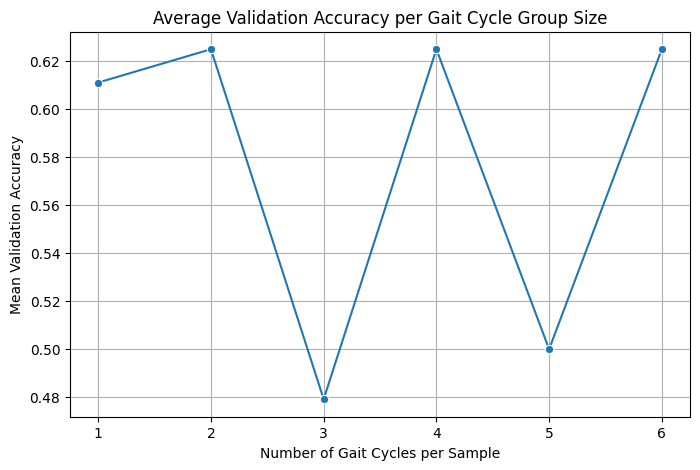

Best cycle size based on validation accuracy: 2


In [27]:
# Convert to DataFrame
results_df = pd.DataFrame(all_results)

# Compute mean accuracy per cycle size
mean_results = results_df.groupby('cycle_size')['accuracy'].mean().reset_index()

# Plot mean accuracy vs cycle size
plt.figure(figsize=(8, 5))
sns.lineplot(data=mean_results, x='cycle_size', y='accuracy', marker='o')
plt.title("Average Validation Accuracy per Gait Cycle Group Size")
plt.xlabel("Number of Gait Cycles per Sample")
plt.ylabel("Mean Validation Accuracy")
plt.grid()
plt.show()

# Select best cycle size based on feature selection approach
best_cycle_size = mean_results.loc[mean_results['accuracy'].idxmax(), 'cycle_size']
print(f"Best cycle size based on validation accuracy: {best_cycle_size}")

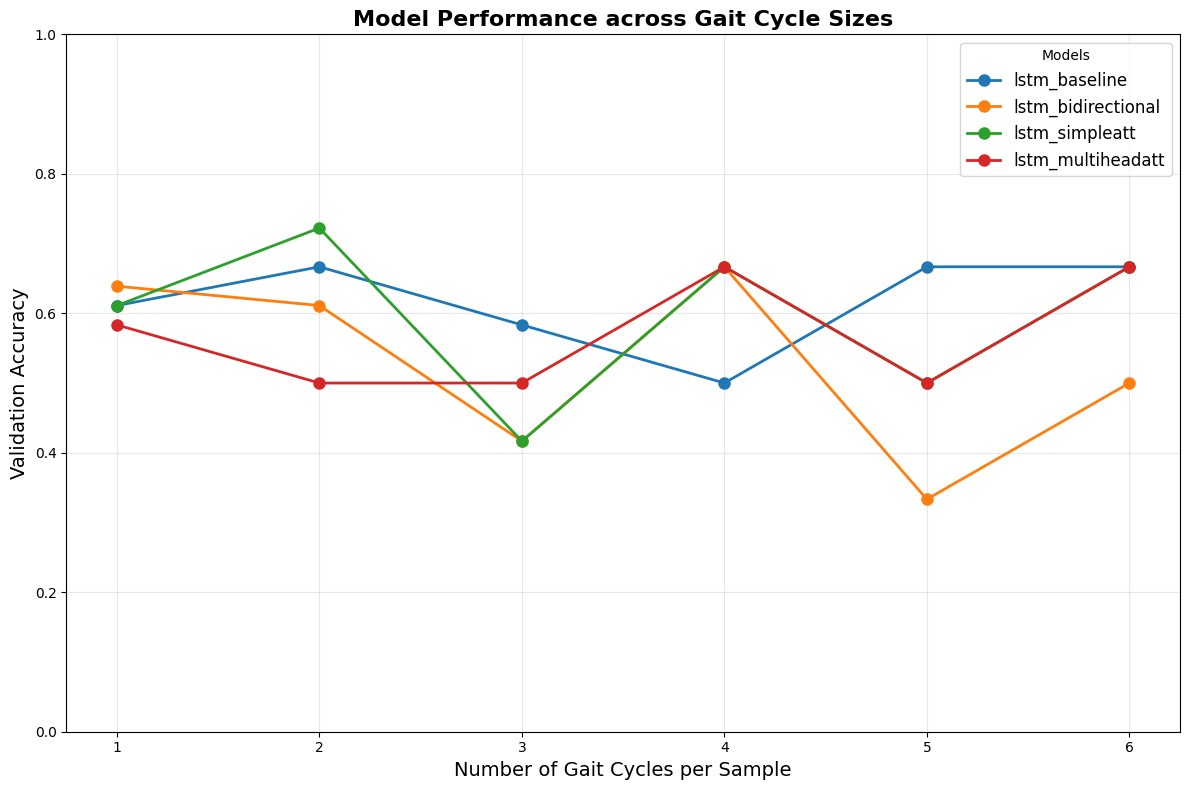

In [28]:
plt.figure(figsize=(12, 8))

# Get unique model names and assign colors
model_names = results_df['model_name'].unique()
colors = sns.color_palette('tab10', n_colors=len(model_names))

# Plot each model's accuracy across cycle sizes
for i, model in enumerate(model_names):
    subset = results_df[results_df['model_name'] == model]
    plt.plot(
        subset['cycle_size'],
        subset['accuracy'],
        marker='o',
        linewidth=2,
        markersize=8,
        color=colors[i],
        label=model
    )

plt.xlabel('Number of Gait Cycles per Sample', fontsize=14)
plt.ylabel('Validation Accuracy', fontsize=14)
plt.title('Model Performance across Gait Cycle Sizes', fontsize=16, fontweight='bold')
plt.xticks(sorted(results_df['cycle_size'].unique()))
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(title='Models', fontsize=12)
plt.tight_layout()

plt.show()

In [29]:
# Summary table: accuracy vs cycle size for every approach
summary = results_df_engineered.pivot_table(index='cycle_size', columns='approach', values='accuracy', aggfunc='mean')
print("Validation Accuracy by Cycle Size and Approach:")
display(summary)

Validation Accuracy by Cycle Size and Approach:


approach,full_features
cycle_size,
1,0.611111
2,0.625000
3,0.479167
4,0.625000
5,0.500000
6,0.625000


**Select Best Model**

In [30]:
# summary of each cyle size with respective models based on feature approach
summary = results_df_engineered.pivot_table(
    index=['approach', 'cycle_size'],
    columns='model_name',
    values='accuracy',
    aggfunc='mean'
).round(4)

print("Validation Accuracy Matrix (Cycle Size × Model):")
display(summary)

Validation Accuracy Matrix (Cycle Size × Model):


model_name                lstm_baseline  lstm_bidirectional  \
approach      cycle_size                                      
full_features 1                  0.6111              0.6389   
              2                  0.6667              0.6111   
              3                  0.5833              0.4167   
              4                  0.5000              0.6667   
              5                  0.6667              0.3333   
              6                  0.6667              0.5000   

model_name                lstm_multiheadatt  lstm_simpleatt  
approach      cycle_size                                     
full_features 1                      0.5833          0.6111  
              2                      0.5000          0.7222  
              3                      0.5000          0.4167  
              4                      0.6667          0.6667  
              5                      0.5000          0.5000  
              6                      0.6667          0.6667

In [31]:
# summary of evaluation metrics for each models with average cycles accuracy, precision, recall, f1_score, roc_auc
metrics_summary = results_df_engineered.pivot_table(
    index='model_name',
    values=['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc'],
    aggfunc='mean'
).round(4)

print("Evaluation Metrics Summary:")
display(metrics_summary)

Evaluation Metrics Summary:


,accuracy,f1_score,precision,recall,roc_auc
model_name,,,,,
lstm_baseline,0.6157,0.5720,0.5110,0.6667,0.6157
lstm_bidirectional,0.5278,0.5767,0.5044,0.7130,0.5278
lstm_multiheadatt,0.5694,0.5250,0.4704,0.6389,0.5694
lstm_simpleatt,0.5972,0.6903,0.5758,0.8889,0.5972


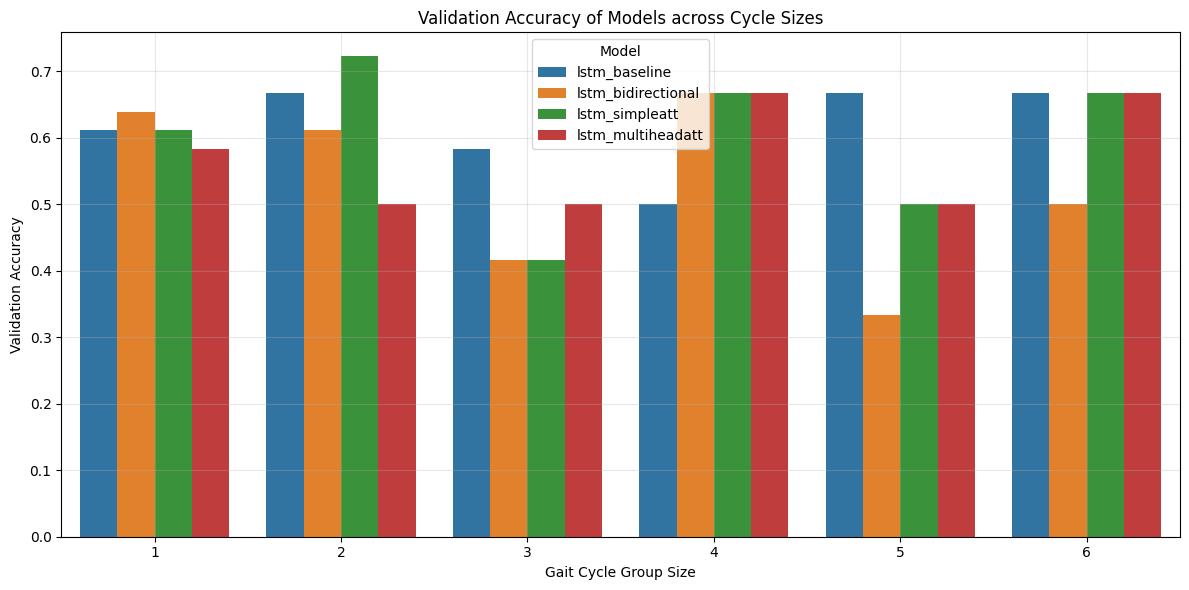

In [32]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=results_df_engineered, x='cycle_size', y='accuracy', hue='model_name', ci=None)

plt.title('Validation Accuracy of Models across Cycle Sizes')
plt.xlabel('Gait Cycle Group Size')
plt.ylabel('Validation Accuracy')
plt.legend(title='Model')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Find Best Configuration**

In [33]:
# Select best approach by mean validation accuracy
best_approach = results_df_engineered.groupby('approach')['accuracy'].mean().idxmax()
best_features = results_df_engineered[results_df_engineered['approach'] == best_approach]

# Select best cycle size within that approach (by mean accuracy)
best_cycle_size = best_features.groupby('cycle_size')['accuracy'].mean().idxmax()
best_cycle = best_features[best_features['cycle_size'] == best_cycle_size]

# Select best model within that cycle size (highest accuracy row)
best_model = best_cycle.loc[best_cycle['accuracy'].idxmax()]
best_model_name = best_model['model_name']

print("\nBEST VALIDATION CONFIGURATION")
print("-" * 40)
print(f"Approach   : {best_approach}")
print(f"Cycle Size : {best_cycle_size}")
print(f"Model      : {best_model_name}")
print(f"Val Acc    : {best_model['accuracy']:.4f}")


BEST VALIDATION CONFIGURATION
----------------------------------------
Approach   : full_features
Cycle Size : 2
Model      : lstm_simpleatt
Val Acc    : 0.7222


In [34]:
# Load data and build best model
print("Loading best configuration data...")

# Load train, val, and test data from the best approach and cycle size
X_train_raw = approach_splits[best_approach][best_cycle_size]['X_train']
X_val_raw = approach_splits[best_approach][best_cycle_size]['X_val']
y_train = approach_splits[best_approach][best_cycle_size]['y_train']
y_val = approach_splits[best_approach][best_cycle_size]['y_val']

print(f"Train data shape: {X_train_raw.shape}")
print(f"Val data shape: {X_val_raw.shape}")

# Create and fit scaler on training data of the best configuration
scaler_best = StandardScaler()
X_train_flat = X_train_raw.reshape(-1, X_train_raw.shape[-1])
scaler_best.fit(X_train_flat)

# Transform train, val, and test data
X_train_3d = scaler_best.transform(X_train_flat).reshape(X_train_raw.shape)
X_val_3d = scaler_best.transform(X_val_raw.reshape(-1, X_val_raw.shape[-1])).reshape(X_val_raw.shape)

print(f"Data scaled using scaler fitted on {X_train_flat.shape[1]} features")

# Build and train the best model
input_shape = (X_train_3d.shape[1], X_train_3d.shape[2])
model_best = models[best_model_name](input_shape)

# Compile the model
model_best.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\nTraining {best_model_name} on best configuration...")
history = model_best.fit(
    X_train_3d, y_train,
    validation_data=(X_val_3d, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[
        EarlyStopping(patience=12, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=6)
    ],
    verbose=1
)

# Save the best model and scaler
os.makedirs(OUTPUT_DIR / "results", exist_ok=True)
model_save_path = OUTPUT_DIR / f"results/{best_approach}_{best_model_name}_{best_cycle_size}cycles.weights.h5"
scaler_save_path = OUTPUT_DIR / f"results/{best_approach}_{best_model_name}_{best_cycle_size}cycles_scaler.pkl"

model_best.save_weights(str(model_save_path))
joblib.dump(scaler_best, str(scaler_save_path))
    
print(f"Model weights saved to: {model_save_path}")
print(f"Scaler saved to: {scaler_save_path}")

Loading best configuration data...
Train data shape: (84, 120, 1)
Val data shape: (18, 120, 1)
Data scaled using scaler fitted on 1 features

Training lstm_simpleatt on best configuration...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 27s 808ms/step - accuracy: 0.5357 - loss: 0.7743 - val_accuracy: 0.4444 - val_loss: 0.6973 - learning_rate: 0.0010
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - accuracy: 0.5000 - loss: 0.7526 - val_accuracy: 0.5000 - val_loss: 0.6951 - learning_rate: 0.0010
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.5714 - loss: 0.6854 - val_accuracy: 0.5000 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.4762 - loss: 0.7633 - val_accuracy: 0.5000 - val_loss: 0.6911 - learning_rate: 0.0010
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - accuracy: 0.5476 - loss: 0.6961 - val_accuracy: 0.5000 - val_loss: 0.6890 - learning_rate: 0.0010
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accura

Generating validation predictions...
X_val_3d shape: (18, 120, 1)
y_val shape: (18,)
y_val_prob shape: (18, 1)
y_val_pred shape after conversion: (18,)
y_val_pred: [1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1]


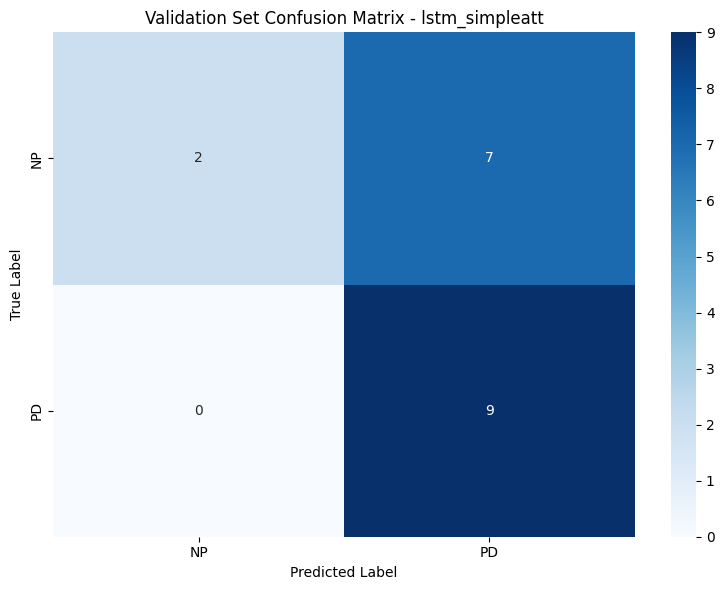


Validation Set Shapes:
y_val: (18,)
y_val_pred: (18,)


In [35]:
# Generate validation predictions
print(f"Generating validation predictions...")
print(f"X_val_3d shape: {X_val_3d.shape}")
print(f"y_val shape: {y_val.shape}")

y_val_prob = model_best.predict(X_val_3d, verbose=0)
print(f"y_val_prob shape: {y_val_prob.shape}")

# Flatten predictions properly
if len(y_val_prob.shape) > 1 and y_val_prob.shape[1] == 1:
    y_val_pred = (y_val_prob[:, 0] > 0.5).astype(int)
else:
    y_val_pred = (y_val_prob > 0.5).astype(int).flatten()

print(f"y_val_pred shape after conversion: {y_val_pred.shape}")
print(f"y_val_pred: {y_val_pred}")

# Confusion matrix visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NP', 'PD'], yticklabels=['NP', 'PD'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Validation Set Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

print(f"\nValidation Set Shapes:")
print(f"y_val: {y_val.shape}")
print(f"y_val_pred: {y_val_pred.shape}")

In [36]:
import joblib

# save the best model and scaler
model_instance = None

# Prefer an actual Keras Model instance if available
for candidate_name in ('best_model', 'model_for_test', 'model'):
	if candidate_name in globals():
		candidate = globals()[candidate_name]
		# check if it's a Keras Model instance
		if isinstance(candidate, Model):
			model_instance = candidate
			break

# If we don't have a model instance, try to recreate it from the factory using best_model_name
if model_instance is None:
	if 'best_model_name' in globals() and best_model_name in models:
		# determine an input shape to instantiate the model
		if 'X_test_scaled' in globals() and X_test_scaled is not None:
			input_shape = (X_test_scaled.shape[1], X_test_scaled.shape[2])
		elif 'X_train' in globals() and X_train is not None:
			input_shape = (X_train.shape[1], X_train.shape[2])
		else:
			input_shape = (TIMESTEPS, KEYPOINTS_PER_TIMESTEP)

		# instantiate model
		model_instance = models[best_model_name](input_shape)

		# attempt to load saved weights if available
		weights_path = OUTPUT_DIR / f"results/{best_model_name}_{best_cycle_size}cycles_weights.h5"
		if weights_path.exists():
			try:
				model_instance.load_weights(str(weights_path))
				print(f"Loaded weights from {weights_path}")
			except Exception as e:
				print(f"Warning: could not load weights from {weights_path}: {e}")
	else:
		raise NameError(
			"No trained model instance found and cannot recreate model. "
			"Ensure you have a Keras model in 'best_model', 'model_for_test' or 'model', "
			"or that 'best_model_name' is set and present in the 'models' dict."
		)

# Save model and scaler (use string paths for compatibility)
save_path = OUTPUT_DIR / f"best_model_{best_model_name}_{best_cycle_size}cycles.h5"
model_instance.save(str(save_path))
joblib.dump(scaler, str(OUTPUT_DIR / f"scaler_{best_cycle_size}cycles.pkl"))
print(f"Saved model to {save_path} and scaler to {OUTPUT_DIR / f'scaler_{best_cycle_size}cycles.pkl'}")

Saved model to models\turn_features\best_model_lstm_simpleatt_2cycles.h5 and scaler to models\turn_features\scaler_2cycles.pkl


**Final Test Evaluation**

In [37]:
# Load test data from the best approach and cycle size
X_test = approach_splits[best_approach][best_cycle_size]['X_test']
y_test = approach_splits[best_approach][best_cycle_size]['y_test']

print(f"Test data shape: {X_test.shape}")

X_test_flat = X_test.reshape(-1, X_test.shape[2])
X_test_scaled = scaler_best.transform(X_test_flat).reshape(X_test.shape)

print(f"Data scaled using scaler fitted on {X_train_flat.shape[1]} features")

# Build and train the best model
input_shape = (X_train_3d.shape[1], X_train_3d.shape[2])
model_best = models[best_model_name](input_shape)

# Make predictions on test set
y_test_prob = model_best.predict(X_test_scaled, verbose=0)
y_test_pred = (y_test_prob > 0.5).astype(int).flatten()

# Calculate evaluation metrics
test_metrics = evaluation_metrics(y_test, y_test_pred)

print(f"\n{'='*60}")
print(f"TEST SET PERFORMANCE")
print(f"{'='*60}")
for metric_name, value in test_metrics.items():
    print(f"{metric_name:20}: {value:.4f}")
print(f"{'='*60}\n")

Test data shape: (18, 120, 1)
Data scaled using scaler fitted on 1 features

TEST SET PERFORMANCE
accuracy            : 0.7778
precision           : 0.7273
recall              : 0.8889
f1_score            : 0.8000
roc_auc             : 0.7778



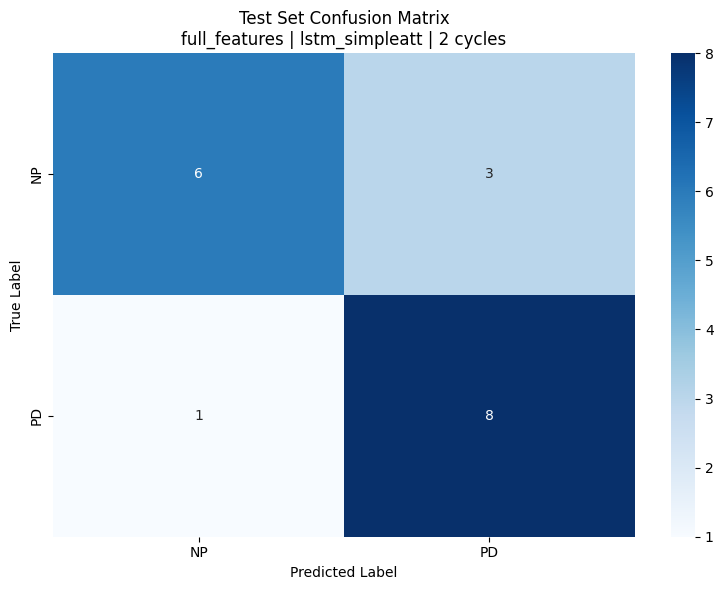


Detailed Classification Report:
              precision    recall  f1-score   support

          NP       0.86      0.67      0.75         9
          PD       0.73      0.89      0.80         9

    accuracy                           0.78        18
   macro avg       0.79      0.78      0.78        18
weighted avg       0.79      0.78      0.77        18



In [38]:
# Visualize confusion matrix for test set
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NP', 'PD'], yticklabels=['NP', 'PD'])
plt.title(f'Test Set Confusion Matrix\n{best_approach} | {best_model_name} | {best_cycle_size} cycles')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Print detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['NP', 'PD']))

In [39]:
# Save test predictions and metrics
test_results = {
    'approach': best_approach,
    'model_name': best_model_name,
    'cycle_size': best_cycle_size,
    'y_test': y_test,
    'y_test_pred': y_test_pred,
    'y_test_prob': y_test_prob.flatten(),
    'metrics': test_metrics
}

# Save to pickle file
import pickle
results_path = OUTPUT_DIR / f"results/test_results_{best_approach}_{best_model_name}_{best_cycle_size}cycles.pkl"
with open(results_path, 'wb') as f:
    pickle.dump(test_results, f)

print(f"Test results saved to: {results_path}")

Test results saved to: models\turn_features\results\test_results_full_features_lstm_simpleatt_2cycles.pkl


**Features Visualization**

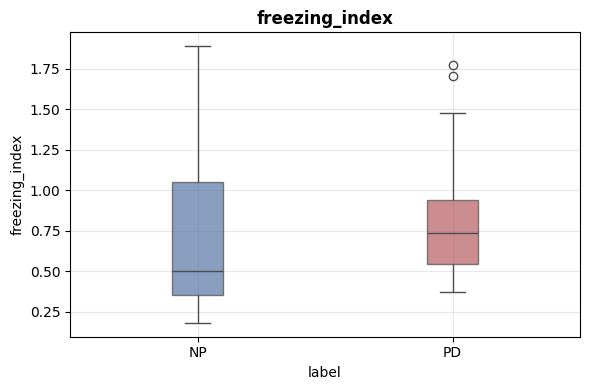

In [40]:
# 8.4 Freezing Index Boxplot
# Visualize only the freezing_index feature
FEATURE_COLS = ['freezing_index']

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_features, x='label', y='freezing_index', ax=ax,
            palette=['#4C72B0', '#C44E52'], width=0.2, boxprops=dict(alpha=0.7))
ax.set_xticklabels(['NP', 'PD'])
ax.set_title('freezing_index', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

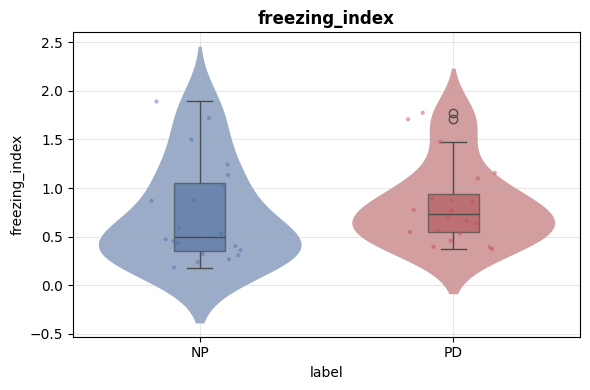

In [41]:
# 8.5 Freezing Index Distribution (Violin + Box + Strip)
# Visualize only the freezing_index feature
FEATURE_COLS = ['freezing_index']

fig, ax = plt.subplots(figsize=(6, 4))
# Violin background
sns.violinplot(data=df_features, x='label', y='freezing_index', ax=ax,
               palette=['#4C72B0', '#C44E52'], inner=None, linewidth=0, alpha=0.6)
# Box plot
sns.boxplot(data=df_features, x='label', y='freezing_index', ax=ax,
            palette=['#4C72B0', '#C44E52'], width=0.2, boxprops=dict(alpha=0.7))
# Strip plot (individual points)
sns.stripplot(data=df_features, x='label', y='freezing_index', ax=ax,
              jitter=0.2, alpha=0.5, size=3, palette=['#4C72B0', '#C44E52'])

ax.set_xticklabels(['NP', 'PD'])
ax.set_title('freezing_index', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

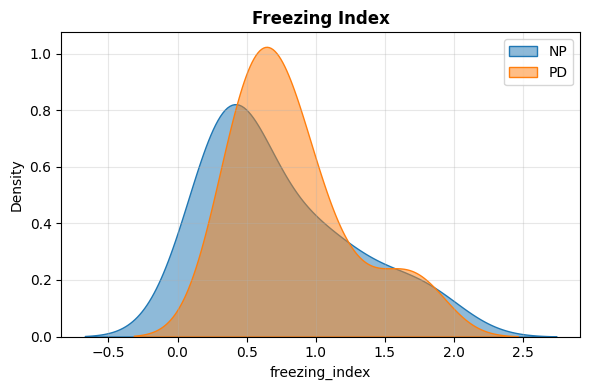

In [42]:
# 8.8 Freezing Index KDE Plot (NP vs PD Density Comparison)
# Visualize only the freezing_index feature

df_np = df_features[df_features['label'] == 0]
df_pd = df_features[df_features['label'] == 1]

fig, ax = plt.subplots(figsize=(6, 4))

# Plot KDEs
try:
    sns.kdeplot(data=df_np, x='freezing_index', label='NP', fill=True, alpha=0.5, ax=ax)
    sns.kdeplot(data=df_pd, x='freezing_index', label='PD', fill=True, alpha=0.5, ax=ax)
    
    ax.set_title('Freezing Index', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
except Exception:
    ax.text(0.5, 0.5, 'KDE failed for freezing_index', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

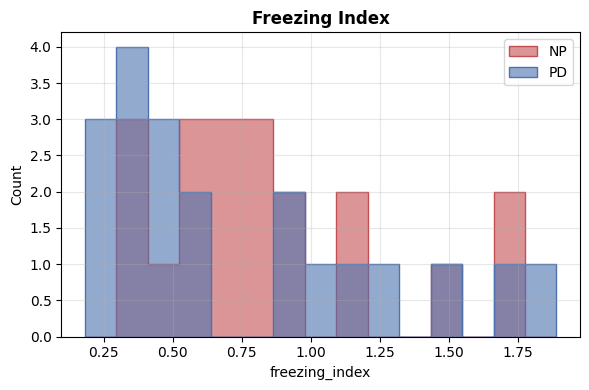

In [43]:
# 8.9 Freezing Index Histogram (NP vs PD)

fig, ax = plt.subplots(figsize=(6, 4))
data = df_features[['freezing_index', 'label']].dropna()

if data.empty:
    ax.text(0.5, 0.5, 'No data for freezing_index', ha='center', va='center')
    ax.set_axis_off()
else:
    sns.histplot(data=data, x='freezing_index', hue='label', bins=15,
                 palette=['#4C72B0', '#C44E52'], alpha=0.6,
                 element='step', stat='count', ax=ax)
    ax.set_title('Freezing Index', fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)
    ax.legend(labels=['NP', 'PD'])

plt.tight_layout()
plt.show()

In [44]:
# 8.10 Summary Statistics
# Compute summary statistics
summary_stats = df_features[FEATURE_COLS].agg(['min', 'max', 'mean', 'std']).T
summary_stats['range'] = summary_stats['max'] - summary_stats['min']

# Add group-wise statistics
for label_name, label_val in [('NP', 0), ('PD', 1)]:
    group_data = df_features[df_features['label'] == label_val][FEATURE_COLS]
    summary_stats[f'{label_name}_mean'] = group_data.mean()
    summary_stats[f'{label_name}_std'] = group_data.std()

# Create a cleaner display version for the notebook
display_df = summary_stats[['min', 'max', 'mean', 'std', 'NP_mean', 'PD_mean']].copy()
display_df.columns = ['Min', 'Max', 'Overall Mean', 'Overall Std', 'NP Mean', 'PD Mean']
display_df.index.name = 'Feature'

print("\nFeature Statistics Table:")
display(display_df)


Feature Statistics Table:


,Min,Max,Overall Mean,Overall Std,NP Mean,PD Mean
Feature,,,,,,
freezing_index,0.181974,1.889989,0.785958,0.466642,0.740249,0.831666
